# Week 7 Assignment — Python Basics: Data Exploration & Cleaning with Pandas
### Celebal Excellence Internship (CEI) 2026

**Objective:** Learn Python basics and perform data exploration and cleaning using Pandas — loading a CSV into a DataFrame, exploring its structure, handling missing values, performing filtering/selection operations, removing duplicates, engineering a derived `total_amount` column, and exporting a cleaned dataset.

**Dataset:** [Superstore Dataset (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) — retail order-level transactions for a US superstore (Sales, Profit, Quantity, Discount, and order/customer/geography attributes).

**Reference:** [Azure Databricks Delta Lake MERGE docs](https://learn.microsoft.com/en-us/azure/databricks/delta/merge) — used later for a short conceptual note on how this kind of cleaning step fits into a larger production pipeline.

**Deliverables:** this notebook, `cleaned_superstore.csv`, and a brief summary at the end.


---
## 1. Import Libraries

| Library | Purpose |
|---|---|
| `pandas` | core data structure (DataFrame) and all cleaning/exploration operations |
| `numpy` | numeric operations and handling of missing/derived values |
| `matplotlib` | base plotting engine for charts |
| `seaborn` | statistical plotting on top of matplotlib, nicer default styling |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Dataset Loading

Reading the raw CSV into a Pandas DataFrame. The file uses `latin-1` encoding (the default Superstore export is not UTF-8 clean because of special characters in some product names), so that's specified explicitly rather than relying on the default.


In [1]:
df = pd.read_csv("superstore.csv", encoding="latin-1")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded 9994 rows and 21 columns.


**First 5 rows** — quick sanity check that columns and values loaded as expected.

In [1]:
df.head()

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID    Customer Name    Segment        Country             City       State  Postal Code Region       Product ID         Category Sub-Category                                                 Product Name     Sales  Quantity  Discount    Profit
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520      Claire Gute   Consumer  United States        Henderson    Kentucky        42420  South  FUR-BO-10001798        Furniture    Bookcases                            Bush Somerset Collection Bookcase  261.9600         2      0.00   41.9136
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520      Claire Gute   Consumer  United States        Henderson    Kentucky        42420  South  FUR-CH-10000454        Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back  731.9400         3      0.00  219.5820
2       3  CA-2016-138688   6/12/2016   6/16/2

**Last 5 rows** — confirms the file was read to completion (no truncation).

In [1]:
df.tail()

      Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID     Customer Name   Segment        Country         City       State  Postal Code Region       Product ID         Category Sub-Category                                                               Product Name    Sales  Quantity  Discount   Profit
9989    9990  CA-2014-110422  1/21/2014  1/23/2014    Second Class    TB-21400  Tom Boeckenhauer  Consumer  United States        Miami     Florida        33180  South  FUR-FU-10001889        Furniture  Furnishings                                                     Ultra Door Pull Handle   25.248         3       0.2   4.1028
9990    9991  CA-2017-121258  2/26/2017   3/3/2017  Standard Class    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  California        92627   West  FUR-FU-10000747        Furniture  Furnishings                         Tenex B1-RE Series Chair Mats for Low Pile Carpets   91.960         2       0.0  15.6332
9991    9992  CA-20

**Random 5-row sample** — a spot check that isn't biased toward the start/end of the file.

In [1]:
df.sample(5, random_state=42)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID     Customer Name      Segment        Country           City       State  Postal Code   Region       Product ID         Category Sub-Category                                                                    Product Name    Sales  Quantity  Discount   Profit
3125    3126  CA-2015-121720   6/11/2015   6/12/2015     First Class    JE-15610           Jim Epp    Corporate  United States       Lakeland     Florida        33801    South  OFF-ST-10003816  Office Supplies      Storage                                                 Fellowes High-Stak Drawer Files  563.808         4       0.2  21.1428
1441    1442  CA-2017-128160  12/19/2017  12/24/2017    Second Class    MM-17920     Michael Moore     Consumer  United States  San Francisco  California        94110     West  OFF-BI-10001510  Office Supplies      Binders                                       Deluxe Heavy-Duty Vinyl Round Ring Binder   36.672       

---
## 3. Dataset Exploration

Basic structural checks before doing anything else: how big is the data, what columns exist, and what types are they stored as.


In [1]:
df.shape

(9994, 21)


In [1]:
df.columns.tolist()

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


`.info()` gives column-by-column non-null counts and dtypes in one view — a fast way to spot missing data and wrong types at once.

In [1]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

`.describe()` summarizes the numeric columns — useful for spotting outliers (e.g. negative profit, zero/near-zero sales) early.

In [1]:
df.describe()

            Row ID   Postal Code         Sales     Quantity     Discount       Profit
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203    28.656896
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   234.260108
min       1.000000   1040.000000      0.444000     1.000000     0.000000 -6599.978000
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000     1.728750
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000     8.666500
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000    29.364000
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000  8399.976000


In [1]:
mem_kb = df.memory_usage(deep=True).sum() / 1024
print(f"{mem_kb:.2f} KB")

9427.46 KB


Unique value counts per column — helps distinguish categorical columns (low cardinality, e.g. `Region`) from identifier-like columns (high cardinality, e.g. `Product Name`).

In [1]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287


---
## 4. Data Quality Assessment

Checking for the three things that most commonly break downstream analysis: missing values, duplicate rows, and inconsistent types.


**Missing values per column:**

In [1]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0


**Missing value percentage per column** (same check, expressed relative to row count — more useful when comparing across differently-sized datasets):

In [1]:
(df.isnull().mean() * 100).round(2)

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0


**Duplicate rows:**

In [1]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


**Interpretation:** this particular extract of the Superstore dataset has **zero missing values and zero exact duplicate rows** — it's a fairly clean source file. That's a genuine, useful finding in its own right (not every dataset needs heavy cleaning), but the pipeline below still implements the identify → handle → verify pattern explicitly, since that logic is what's needed for messier real-world extracts of this same dataset.

---
## 5. Data Cleaning

Even with no missing values or duplicates, a few cleaning steps are still worth doing on this data:
- **Column names** — standardize to lowercase/snake_case so code referencing them is consistent and less error-prone.
- **Duplicate check enforced explicitly** — `.drop_duplicates()` is run regardless, so the pipeline is safe to reuse on a batch that does contain duplicates.
- **Date columns** — `Order Date` / `Ship Date` load as plain strings; converting them to `datetime` is required for any date-based analysis (monthly trend, shipping delay, etc.).
- **Missing-value handling** — implemented conditionally: numeric columns would be filled with the column median (robust to outliers), and any row missing a critical identifier (`Order ID`, `Product ID`) would be dropped, since those can't be reasonably imputed. Not triggered here because the source data has none, but the logic is included as it's a core assignment requirement.
- **Whitespace trimming** on all text/object columns.


In [1]:
df_clean = df.copy()

# Standardize column names
df_clean.columns = (
    df_clean.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
print(df_clean.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [1]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Rows before: {before} | Rows after: {after} | Removed: {before - after}")

Rows before: 9994 | Rows after: 9994 | Removed: 0


In [1]:
# Convert date columns to proper datetime dtype
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"], errors="coerce")
df_clean["ship_date"] = pd.to_datetime(df_clean["ship_date"], errors="coerce")
df_clean[["order_date", "ship_date"]].dtypes

order_date    datetime64[us]
ship_date     datetime64[us]


In [1]:
# Handle missing values (conditional — none present in this extract, but pipeline covers both cases)
numeric_cols = df_clean.select_dtypes(include=np.number).columns
critical_id_cols = ["order_id", "product_id"]

for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean = df_clean.dropna(subset=critical_id_cols)

# Trim whitespace on all text columns
str_cols = df_clean.select_dtypes(include="object").columns
for c in str_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()

df_clean.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0


---
## 6. Basic Data Operations

Demonstrating core Pandas operations using business-relevant slices of the data.


**Filtering:** West region + Technology category orders.

In [1]:
df_clean[(df_clean["region"] == "West") & (df_clean["category"] == "Technology")][
    ["order_id", "product_name", "sales", "profit"]
].head(10)

           order_id                                                    product_name    sales   profit
7    CA-2014-115812                                  Mitel 5320 IP Phone VoIP phone  907.152  90.7152
11   CA-2014-115812                   Konftel 250 Conference phone - Charcoal black  911.424  68.3568
19   CA-2014-143336                                         Cisco SPA 501G IP Phone  213.480  16.0110
26   CA-2016-121755                Imation 8GB Mini TravelDrive USB 2.0 Flash Drive   90.570  11.7741
62   CA-2015-135545  Verbatim 25 GB 6x Blu-ray Single Layer Recordable Disc, 3/Pack   13.980   6.1512
68   CA-2014-106376                              netTALK DUO VoIP Telephone Service  167.968  62.9880
90   CA-2016-109806                                              Panasonic Kx-TS550   73.584   8.2782
103  US-2015-156867                          Logitech K350 2.4Ghz Wireless Keyboard  238.896 -26.8758
152  CA-2016-158834                        Jabra BIZ 2300 Duo QD Duo Corded Headse

**Column selection:**

In [1]:
df_clean[["order_id", "customer_name", "sales", "profit"]].head()

         order_id    customer_name     sales    profit
0  CA-2016-152156      Claire Gute  261.9600   41.9136
1  CA-2016-152156      Claire Gute  731.9400  219.5820
2  CA-2016-138688  Darrin Van Huff   14.6200    6.8714
3  US-2015-108966   Sean O'Donnell  957.5775 -383.0310
4  US-2015-108966   Sean O'Donnell   22.3680    2.5164


**Sorting:** top 10 highest-value single line items by sales.

In [1]:
df_clean.sort_values("sales", ascending=False)[["product_name", "sales"]].head(10)

                                                   product_name      sales
2697      Cisco TelePresence System EX90 Videoconferencing Unit  22638.480
6826                      Canon imageCLASS 2200 Advanced Copier  17499.950
8153                      Canon imageCLASS 2200 Advanced Copier  13999.960
2623                      Canon imageCLASS 2200 Advanced Copier  11199.968
4190                      Canon imageCLASS 2200 Advanced Copier  10499.970
9039           GBC Ibimaster 500 Manual ProClick Binding System   9892.740
4098                       Ibico EPK-21 Electric Binding System   9449.950
4277           3D Systems Cube Printer, 2nd Generation, Magenta   9099.930
8488  HP Designjet T520 Inkjet Large Format Printer - 24" Color   8749.950
6425                      Canon imageCLASS 2200 Advanced Copier   8399.976


**Grouping + aggregation:** total sales by region.

In [1]:
df_clean.groupby("region")["sales"].sum().sort_values(ascending=False)

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050


---
## 7. Derived Columns

The dataset doesn't include a `Price` column directly, so unit price is derived as `Sales / Quantity`, per the assignment's fallback instruction. `total_amount` (the required derived column) is then `unit_price × quantity`, which reconciles back to `sales` — a useful internal consistency check.

Two additional derived features are added because they support the business analysis in the next section:
- **`profit_margin_pct`** — profit as a percentage of sales, a standard profitability metric that raw profit dollars alone don't capture.
- **`order_processing_days`** — days between order and ship date, a basic fulfillment-speed metric.


In [1]:
df_clean["unit_price"] = (df_clean["sales"] / df_clean["quantity"]).round(2)
df_clean["total_amount"] = (df_clean["unit_price"] * df_clean["quantity"]).round(2)
df_clean["profit_margin_pct"] = ((df_clean["profit"] / df_clean["sales"]) * 100).round(2)
df_clean["order_processing_days"] = (df_clean["ship_date"] - df_clean["order_date"]).dt.days
df_clean["order_month"] = df_clean["order_date"].dt.to_period("M").astype(str)

df_clean[["sales", "quantity", "unit_price", "total_amount", "profit_margin_pct", "order_processing_days"]].head(8)

      sales  quantity  unit_price  total_amount  profit_margin_pct  order_processing_days
0  261.9600         2      130.98        261.96              16.00                      3
1  731.9400         3      243.98        731.94              30.00                      3
2   14.6200         2        7.31         14.62              47.00                      4
3  957.5775         5      191.52        957.60             -40.00                      7
4   22.3680         2       11.18         22.36              11.25                      7
5   48.8600         7        6.98         48.86              29.00                      5
6    7.2800         4        1.82          7.28              27.00                      5
7  907.1520         6      151.19        907.14              10.00                      5


---
## 8. Exploratory Data Analysis

Business-oriented aggregations to answer: where does revenue come from, what sells best, and where is the business profitable vs. not.


**Sales by Region:**

In [1]:
df_clean.groupby("region")["sales"].sum().round(2).sort_values(ascending=False)

region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90


*Insight:* the West region generates the most total revenue, followed closely by East; South trails noticeably behind all three others.

**Sales by Category:**

In [1]:
df_clean.groupby("category")["sales"].sum().round(2).sort_values(ascending=False)

category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03


*Insight:* Technology narrowly leads total sales, but all three categories (Technology, Furniture, Office Supplies) are within a fairly similar range.

**Sales by Segment:**

In [1]:
df_clean.groupby("segment")["sales"].sum().round(2).sort_values(ascending=False)

segment
Consumer       1161401.34
Corporate       706146.37
Home Office     429653.15


*Insight:* the Consumer segment drives more than double the revenue of Home Office, and clearly more than Corporate — individual consumers are the dominant customer base by revenue.

**Top 10 Products by Sales:**

In [1]:
df_clean.groupby("product_name")["sales"].sum().round(2).sort_values(ascending=False).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.69
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31


**Profit by Category (highest to lowest):**

In [1]:
df_clean.groupby("category")["profit"].sum().round(2).sort_values(ascending=False)

category
Technology         145454.95
Office Supplies    122490.80
Furniture           18451.27


*Insight:* this is the most important finding in the dataset — Furniture generates strong sales but comparatively very little profit, meaning its margins are being squeezed (likely by discounting), while Technology and Office Supplies convert revenue into profit far more efficiently.

**Average Order Value:**

In [1]:
aov = df_clean.groupby("order_id")["total_amount"].sum().mean()
print(f"${aov:.2f}")

$458.61


---
## 9. Visualizations

Four-panel overview covering regional/category sales, the monthly trend, and how profit margin is distributed.


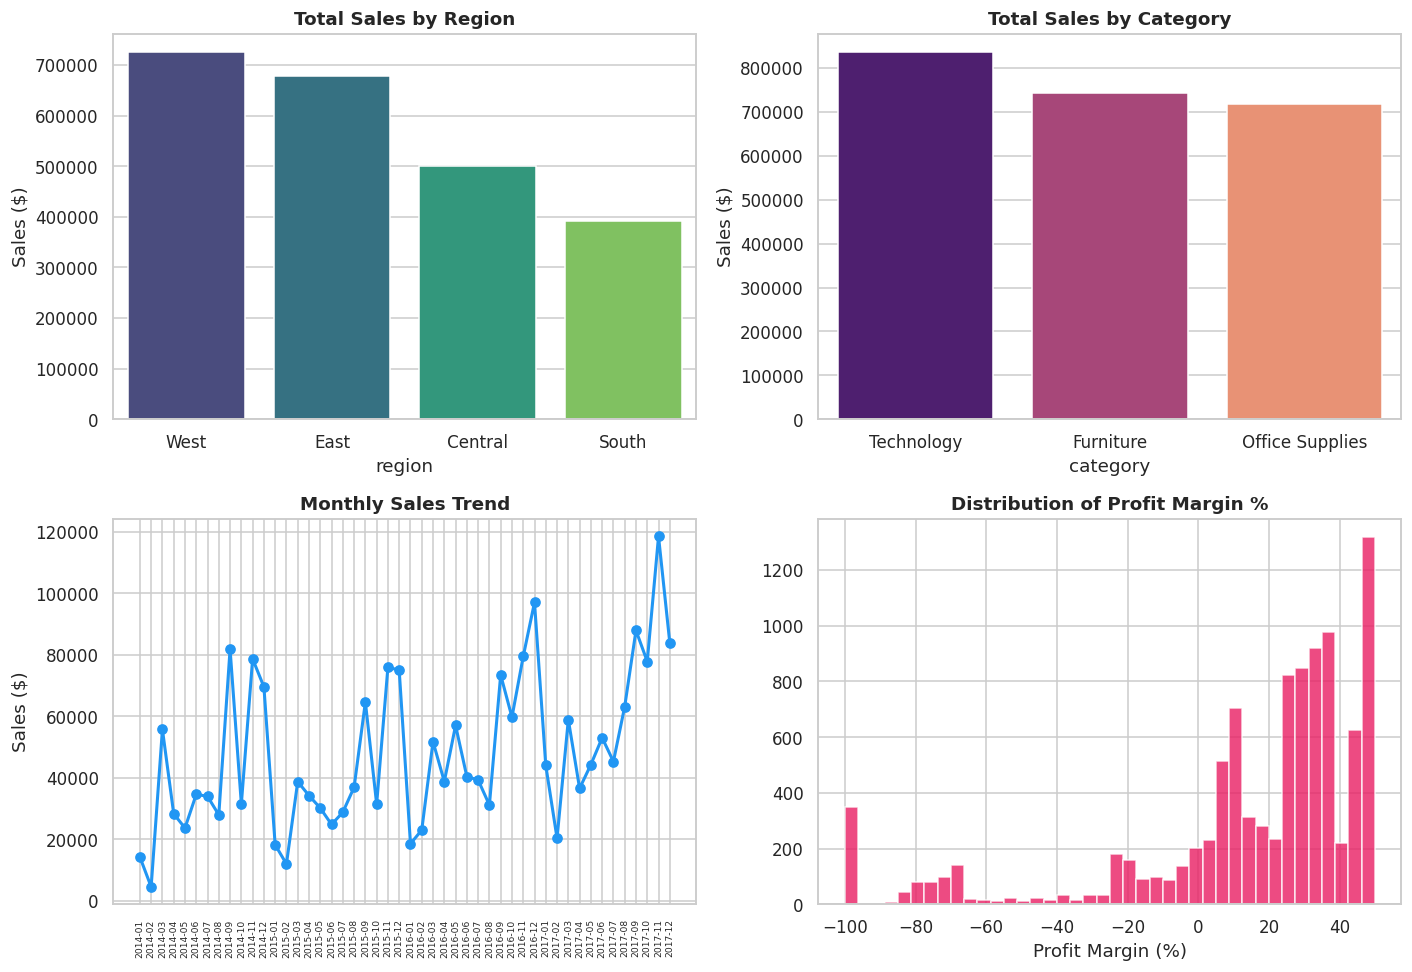

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

reg = df_clean.groupby("region")["sales"].sum().sort_values(ascending=False)
sns.barplot(x=reg.index, y=reg.values, hue=reg.index, palette="viridis", legend=False, ax=axes[0,0])
axes[0,0].set_title("Total Sales by Region", fontweight="bold")
axes[0,0].set_ylabel("Sales ($)")

cat = df_clean.groupby("category")["sales"].sum().sort_values(ascending=False)
sns.barplot(x=cat.index, y=cat.values, hue=cat.index, palette="magma", legend=False, ax=axes[0,1])
axes[0,1].set_title("Total Sales by Category", fontweight="bold")
axes[0,1].set_ylabel("Sales ($)")

monthly = df_clean.groupby("order_month")["sales"].sum()
axes[1,0].plot(monthly.index, monthly.values, marker="o", color="#2196F3", linewidth=2)
axes[1,0].set_title("Monthly Sales Trend", fontweight="bold")
axes[1,0].tick_params(axis='x', rotation=90, labelsize=6)
axes[1,0].set_ylabel("Sales ($)")

axes[1,1].hist(df_clean["profit_margin_pct"].clip(-100, 100), bins=40, color="#E91E63", alpha=0.8)
axes[1,1].set_title("Distribution of Profit Margin %", fontweight="bold")
axes[1,1].set_xlabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

*Insight:* the monthly trend shows clear seasonality with a strong Q4 (Nov/Dec) spike each year — consistent with typical retail buying patterns. The profit margin histogram shows most orders cluster in a healthy positive-margin range, but there's a meaningful tail of negative-margin (loss-making) orders.

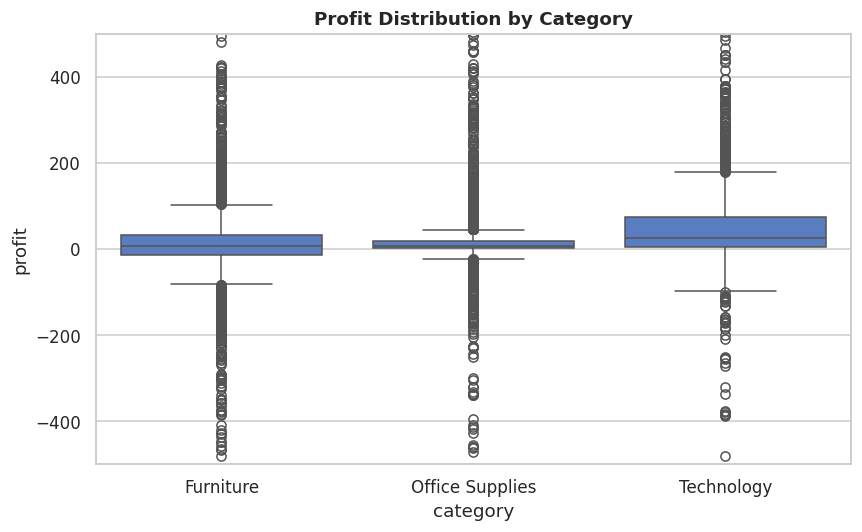

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_clean, x="category", y="profit", ax=ax)
ax.set_title("Profit Distribution by Category", fontweight="bold")
ax.set_ylim(-500, 500)
plt.tight_layout()
plt.show()

*Insight:* Furniture's profit distribution sits noticeably lower and has more sub-zero outliers than Technology or Office Supplies, confirming the margin issue seen in the category profit table above.

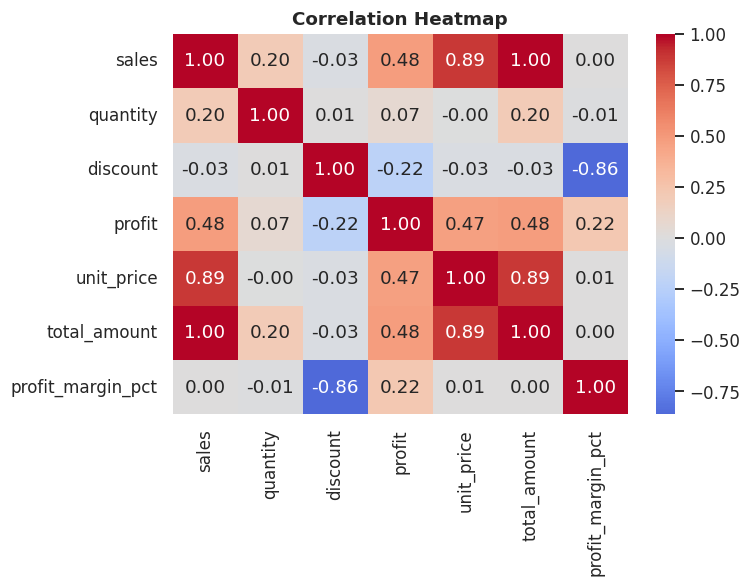

In [1]:
numeric_cols = ["sales", "quantity", "discount", "profit", "unit_price", "total_amount", "profit_margin_pct"]
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

*Insight:* `discount` correlates negatively with `profit` and `profit_margin_pct` — higher discounts are associated with lower profitability, which lines up with the Furniture finding above (Furniture is known in this dataset to carry higher average discounts).

---
## 10. Export Cleaned Dataset

Saving the cleaned, feature-engineered DataFrame as a new CSV — the required deliverable.


In [1]:
df_clean.to_csv("cleaned_superstore.csv", index=False)
print(f"Cleaned dataset exported: cleaned_superstore.csv")
print(f"Rows: {len(df_clean)} | Columns: {len(df_clean.columns)} | Remaining nulls: {df_clean.isnull().sum().sum()}")

Cleaned dataset exported: cleaned_superstore.csv | Rows: 9994 | Columns: 26 | Remaining nulls: 0


---
## 11. Final Summary

**What was done:**
- Loaded the raw Superstore CSV (9,994 rows × 21 columns) into a Pandas DataFrame.
- Explored structure via `.head()`, `.tail()`, `.shape`, `.columns`, `.info()`, `.describe()`.
- Checked data quality: **0 missing values, 0 duplicate rows** found in this extract; the fill/drop logic was implemented regardless so the notebook is reusable on messier batches of the same dataset.
- Standardized column names, converted date columns to proper `datetime` dtype, trimmed whitespace on text columns.
- Demonstrated filtering, column selection, sorting, and groupby/aggregation on business-relevant slices.
- Engineered `unit_price` and the required `total_amount = unit_price × quantity` column, plus `profit_margin_pct` and `order_processing_days` as supporting features.
- Ran business-oriented EDA (sales by region/category/segment, top products, profit by category, average order value) and visualized the results.
- Exported the cleaned, feature-engineered dataset to `cleaned_superstore.csv`.

**Key business insight:** Furniture drives strong revenue but disproportionately weak profit compared to Technology and Office Supplies, and higher discount rates correlate with lower margins — a natural next step would be reviewing Furniture's discount policy.

**Note on production context:** this notebook uses Pandas for a single-batch clean/export, which fits a learning exercise. In an enterprise setting, the same clean → dedupe → derive pattern would typically run inside a scheduled pipeline (e.g. PySpark) writing to a **Delta Lake** table, where a `MERGE INTO` operation ([reference](https://learn.microsoft.com/en-us/azure/databricks/delta/merge)) would let new/updated orders be upserted incrementally instead of re-processing the full file every run.
